Exploratory Data Analysis (EDA) for Pneumonia Chest X-Ray Dataset

Dataset: Kermany et al. (2018) - https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2  
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [3]:
DATA_DIR = Path('../data/chest_xray')
RESULTS_DIR = Path('../results/eda')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
IMG_EXTENSIONS = ['.jpeg']

def count_images_in_directory(directory):
    """Count images in a directory"""
    return len(list(directory.glob('*.jpeg')))

# Analyze dataset structure
dataset_stats = []

for split in ['train', 'test', 'val']:
    split_dir = DATA_DIR / split
    if split_dir.exists():
        for class_name in ['NORMAL', 'PNEUMONIA']:
            class_dir = split_dir / class_name
            if class_dir.exists():
                count = count_images_in_directory(class_dir)
                dataset_stats.append({
                    'Split': split.capitalize(),
                    'Class': class_name,
                    'Count': count
                })
                print(f"{split.upper()}/{class_name}: {count} images")

df_stats = pd.DataFrame(dataset_stats)


TRAIN/NORMAL: 1341 images
TRAIN/PNEUMONIA: 3875 images
TEST/NORMAL: 234 images
TEST/PNEUMONIA: 390 images
VAL/NORMAL: 8 images
VAL/PNEUMONIA: 8 images


In [6]:
print(df_stats)

   Split      Class  Count
0  Train     NORMAL   1341
1  Train  PNEUMONIA   3875
2   Test     NORMAL    234
3   Test  PNEUMONIA    390
4    Val     NORMAL      8
5    Val  PNEUMONIA      8


### SUMMARY STATISTICS

In [7]:
for split in ['Train', 'Test', 'Val']:
    split_data = df_stats[df_stats['Split'] == split]
    total = split_data['Count'].sum()
    normal = split_data[split_data['Class'] == 'NORMAL']['Count'].values[0] if len(split_data[split_data['Class'] == 'NORMAL']) > 0 else 0
    pneumonia = split_data[split_data['Class'] == 'PNEUMONIA']['Count'].values[0] if len(split_data[split_data['Class'] == 'PNEUMONIA']) > 0 else 0
    
    print(f"\n{split} Set:")
    print(f"  Total: {total} images")
    print(f"  Normal: {normal} ({normal/total*100:.1f}%)")
    print(f"  Pneumonia: {pneumonia} ({pneumonia/total*100:.1f}%)")
    print(f"  Imbalance Ratio: 1:{pneumonia/normal:.2f}")

# Overall statistics
total_images = df_stats['Count'].sum()
print(f"\nTotal Dataset Size: {total_images} images")

# Save statistics
df_stats.to_csv(RESULTS_DIR / 'dataset_statistics.csv', index=False)
print(f"\n Statistics saved to: {RESULTS_DIR / 'dataset_statistics.csv'}")


Train Set:
  Total: 5216 images
  Normal: 1341 (25.7%)
  Pneumonia: 3875 (74.3%)
  Imbalance Ratio: 1:2.89

Test Set:
  Total: 624 images
  Normal: 234 (37.5%)
  Pneumonia: 390 (62.5%)
  Imbalance Ratio: 1:1.67

Val Set:
  Total: 16 images
  Normal: 8 (50.0%)
  Pneumonia: 8 (50.0%)
  Imbalance Ratio: 1:1.00

Total Dataset Size: 5856 images

 Statistics saved to: ../results/eda/dataset_statistics.csv


### SAMPLE IMAGES VISUALIZATION

 Sample images saved: ../results/eda/sample_images.png


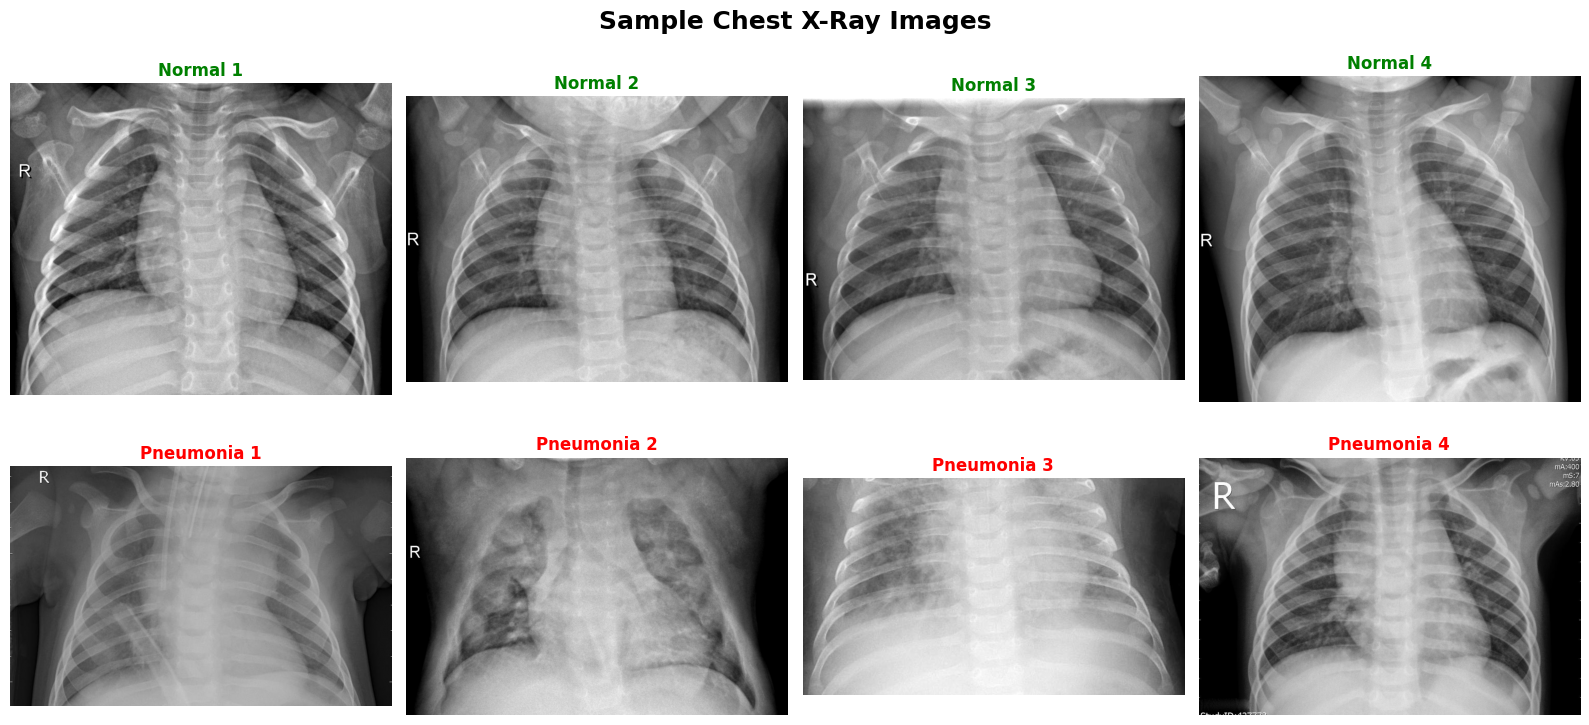

In [8]:
def load_sample_images(class_dir, num_samples=4):
    """Load random sample images from a directory"""
    image_paths = []
    for ext in IMG_EXTENSIONS:
        image_paths.extend(list(class_dir.glob(f'*{ext}')))
    
    # Randomly select samples
    np.random.seed(42)  # For reproducibility
    selected = np.random.choice(image_paths, min(num_samples, len(image_paths)), replace=False)
    
    images = []
    for path in selected:
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            images.append(img)
    
    return images

# Load sample images
normal_dir = DATA_DIR / 'train' / 'NORMAL'
pneumonia_dir = DATA_DIR / 'train' / 'PNEUMONIA'

normal_samples = load_sample_images(normal_dir, num_samples=4)
pneumonia_samples = load_sample_images(pneumonia_dir, num_samples=4)

# Create visualization
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Plot normal samples
for i, img in enumerate(normal_samples):
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'Normal {i+1}', fontsize=12, fontweight='bold', color='green')
    axes[0, i].axis('off')

# Plot pneumonia samples
for i, img in enumerate(pneumonia_samples):
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title(f'Pneumonia {i+1}', fontsize=12, fontweight='bold', color='red')
    axes[1, i].axis('off')

plt.suptitle('Sample Chest X-Ray Images', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sample_images.png', dpi=300, bbox_inches='tight')
print(f" Sample images saved: {RESULTS_DIR / 'sample_images.png'}")
plt.show()

 Class distribution plot saved: ../results/eda/class_distribution.png


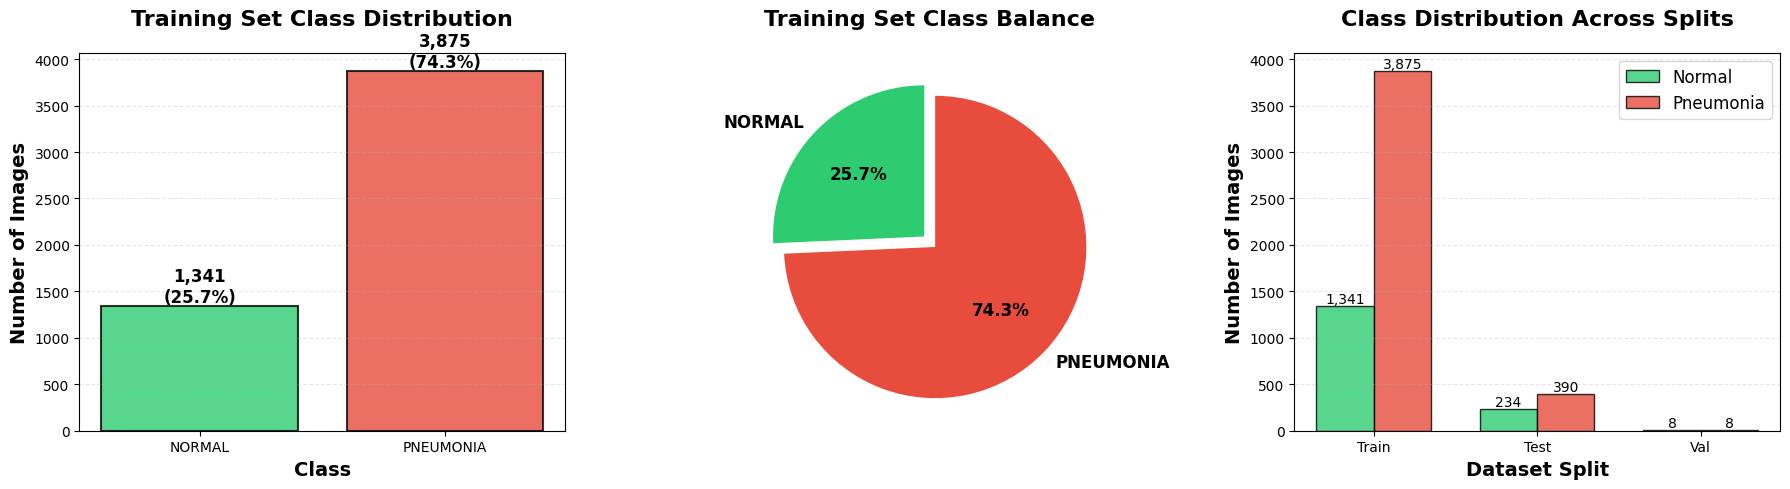

In [9]:
# Prepare data for visualization
train_data = df_stats[df_stats['Split'] == 'Train']
normal_count = train_data[train_data['Class'] == 'NORMAL']['Count'].values[0]
pneumonia_count = train_data[train_data['Class'] == 'PNEUMONIA']['Count'].values[0]

# Create figure with multiple subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Training set distribution (Bar chart)
ax1 = axes[0]
classes = ['NORMAL', 'PNEUMONIA']
counts = [normal_count, pneumonia_count]
colors = ['#2ecc71', '#e74c3c']

bars = ax1.bar(classes, counts, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.set_ylabel('Number of Images', fontsize=14, fontweight='bold')
ax1.set_xlabel('Class', fontsize=14, fontweight='bold')
ax1.set_title('Training Set Class Distribution', fontsize=16, fontweight='bold', pad=20)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    percentage = count / sum(counts) * 100
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{count:,}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Plot 2: Pie chart
ax2 = axes[1]
colors_pie = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.05)
wedges, texts, autotexts = ax2.pie(counts, labels=classes, autopct='%1.1f%%',
                                     colors=colors_pie, explode=explode,
                                     startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('Training Set Class Balance', fontsize=16, fontweight='bold', pad=20)

# Plot 3: All splits comparison
ax3 = axes[2]
splits = ['Train', 'Test', 'Val']
normal_counts = []
pneumonia_counts = []

for split in splits:
    split_data = df_stats[df_stats['Split'] == split]
    normal = split_data[split_data['Class'] == 'NORMAL']['Count'].values[0]
    pneumonia = split_data[split_data['Class'] == 'PNEUMONIA']['Count'].values[0]
    normal_counts.append(normal)
    pneumonia_counts.append(pneumonia)

x = np.arange(len(splits))
width = 0.35

bars1 = ax3.bar(x - width/2, normal_counts, width, label='Normal', 
                color='#2ecc71', edgecolor='black', alpha=0.8)
bars2 = ax3.bar(x + width/2, pneumonia_counts, width, label='Pneumonia',
                color='#e74c3c', edgecolor='black', alpha=0.8)

ax3.set_ylabel('Number of Images', fontsize=14, fontweight='bold')
ax3.set_xlabel('Dataset Split', fontsize=14, fontweight='bold')
ax3.set_title('Class Distribution Across Splits', fontsize=16, fontweight='bold', pad=20)
ax3.set_xticks(x)
ax3.set_xticklabels(splits)
ax3.legend(fontsize=12, loc='upper right')
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'class_distribution.png', dpi=300, bbox_inches='tight')
print(f" Class distribution plot saved: {RESULTS_DIR / 'class_distribution.png'}")
plt.show()

### Image Dimension Analysis (EDA / Data Profiling)

Before starting the modelling phase, we inspect basic image properties across the dataset (train/val/test), namely **width**, **height**, **aspect ratio**, and **file size**.  
This is an **exploratory sanity-check** step (not the final preprocessing pipeline) whose goal is to understand how heterogeneous the images are and to identify potential outliers or inconsistencies.

These statistics help us justify key preprocessing choices required by CNN-based models, such as:
- the **input resolution** to adopt (e.g., 224×224 for many pretrained networks),
- whether resizing may introduce **distortion** (aspect ratio variability),
- whether we should prefer **resize + padding** vs **cropping**,
- and whether there are unusual files (very small/large images or atypical file sizes) that may need filtering.

The outputs are saved as a figure (`dimension_analysis.png`) and a summary table (`dimension_statistics.csv`) for reporting and reproducibility.


Analyzed 680 images

Dimension Statistics:
  Width  - Min: 438, Max: 2752, Mean: 1449.1, Std: 417.0
  Height - Min: 168, Max: 2713, Mean: 1082.7, Std: 432.6
  Aspect Ratio - Mean: 1.409, Std: 0.238
  File Size (KB) - Mean: 233.3, Std: 246.7
✓ Dimension analysis plot saved: ../results/eda/dimension_analysis.png


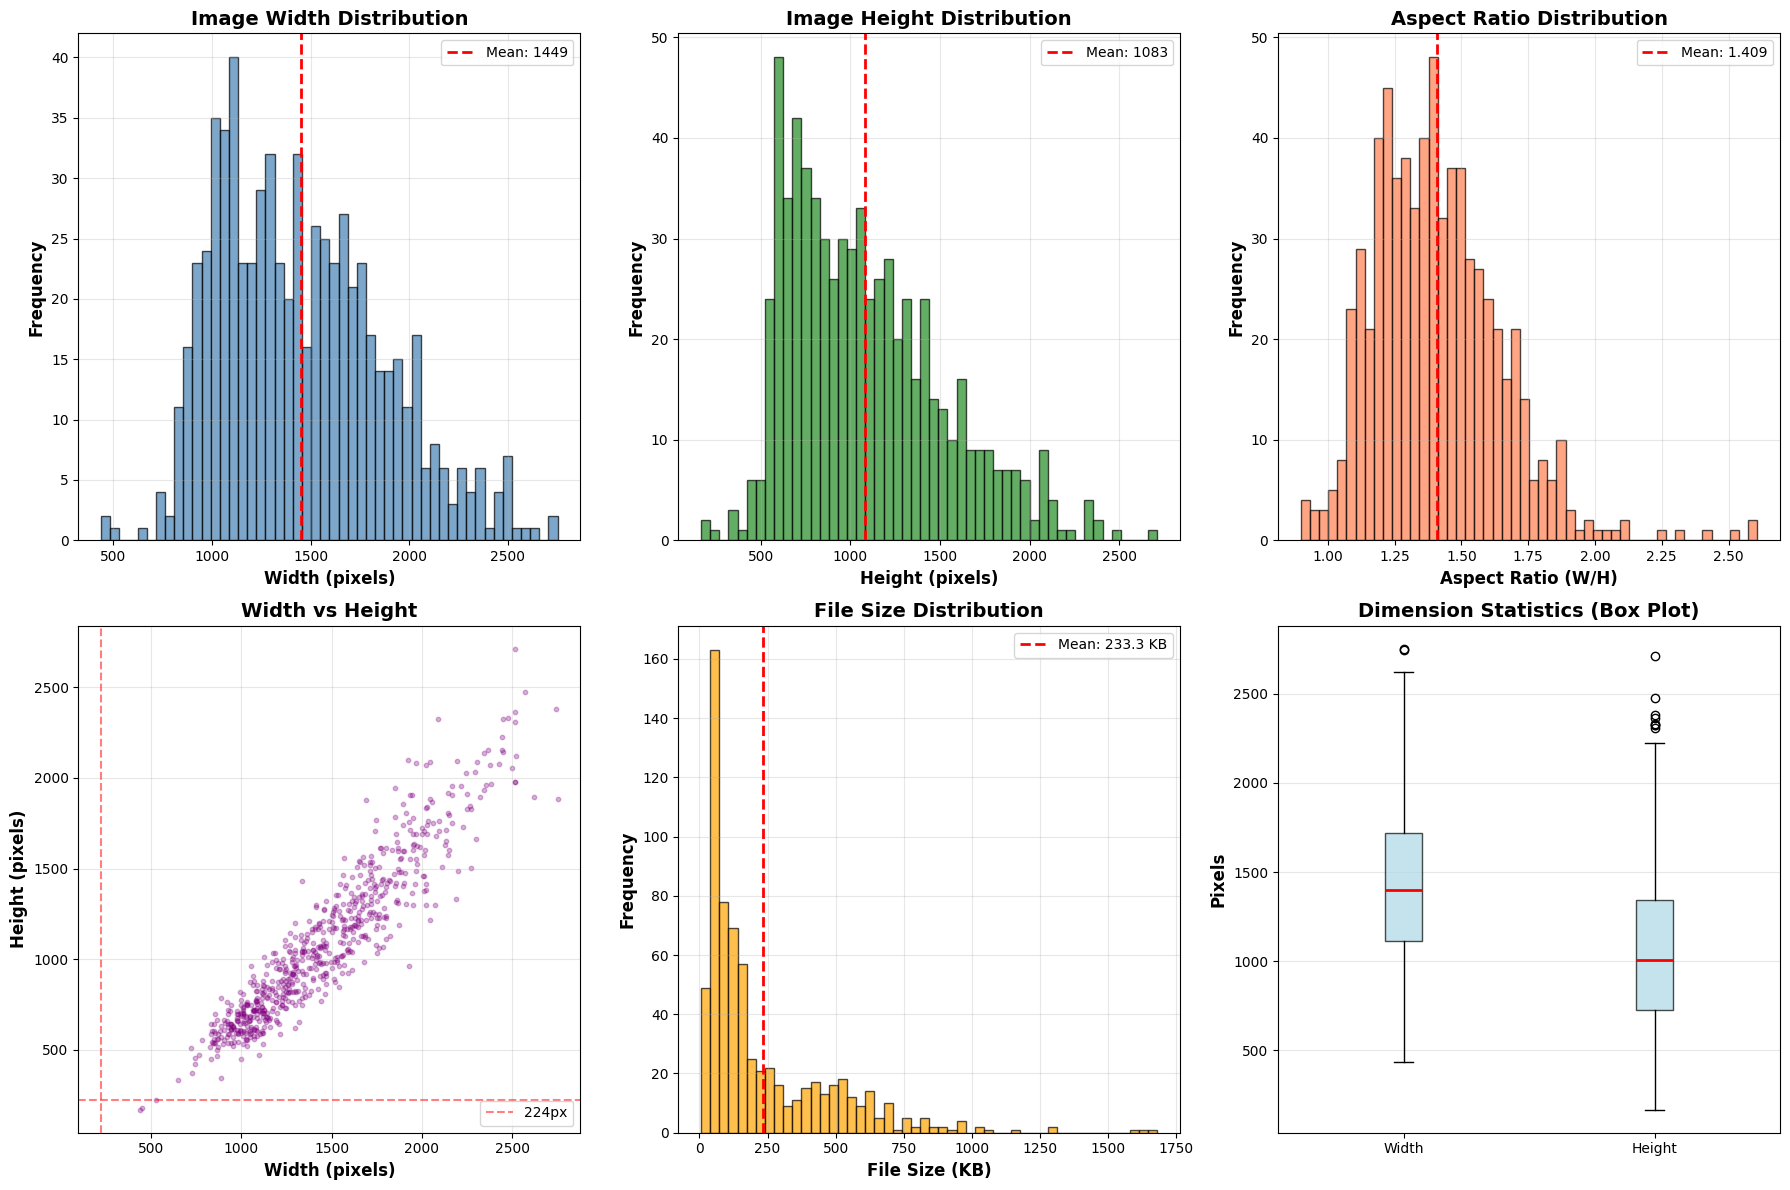

In [10]:
def analyze_dimensions(data_dir, max_samples=1000):
    """Analyze image dimensions across dataset"""
    dimensions = []
    aspect_ratios = []
    file_sizes = []
    
    sample_count = 0
    
    for split in ['train', 'test', 'val']:
        split_dir = data_dir / split
        if not split_dir.exists():
            continue
            
        for class_name in ['NORMAL', 'PNEUMONIA']:
            class_dir = split_dir / class_name
            if not class_dir.exists():
                continue
                
            image_paths = []
            for ext in IMG_EXTENSIONS:
                image_paths.extend(list(class_dir.glob(f'*{ext}')))
            
            # Sample if too many images
            if len(image_paths) > max_samples // 6:
                np.random.seed(42)
                image_paths = np.random.choice(image_paths, max_samples // 6, replace=False)
            
            for img_path in image_paths:
                try:
                    img = Image.open(img_path)
                    width, height = img.size
                    dimensions.append((width, height))
                    aspect_ratios.append(width / height)
                    file_sizes.append(os.path.getsize(img_path) / 1024)  # KB
                    sample_count += 1
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")
    
    print(f"Analyzed {sample_count} images")
    
    return np.array(dimensions), np.array(aspect_ratios), np.array(file_sizes)

# Analyze dimensions
dimensions, aspect_ratios, file_sizes = analyze_dimensions(DATA_DIR)

widths = dimensions[:, 0]
heights = dimensions[:, 1]

# Print statistics
print("\nDimension Statistics:")
print(f"  Width  - Min: {widths.min()}, Max: {widths.max()}, Mean: {widths.mean():.1f}, Std: {widths.std():.1f}")
print(f"  Height - Min: {heights.min()}, Max: {heights.max()}, Mean: {heights.mean():.1f}, Std: {heights.std():.1f}")
print(f"  Aspect Ratio - Mean: {aspect_ratios.mean():.3f}, Std: {aspect_ratios.std():.3f}")
print(f"  File Size (KB) - Mean: {file_sizes.mean():.1f}, Std: {file_sizes.std():.1f}")

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Width distribution
axes[0, 0].hist(widths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(widths.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {widths.mean():.0f}')
axes[0, 0].set_xlabel('Width (pixels)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Image Width Distribution', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Height distribution
axes[0, 1].hist(heights, bins=50, color='forestgreen', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(heights.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {heights.mean():.0f}')
axes[0, 1].set_xlabel('Height (pixels)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Image Height Distribution', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Aspect ratio distribution
axes[0, 2].hist(aspect_ratios, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 2].axvline(aspect_ratios.mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {aspect_ratios.mean():.3f}')
axes[0, 2].set_xlabel('Aspect Ratio (W/H)', fontsize=12, fontweight='bold')
axes[0, 2].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 2].set_title('Aspect Ratio Distribution', fontsize=14, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# Width vs Height scatter
axes[1, 0].scatter(widths, heights, alpha=0.3, s=10, color='purple')
axes[1, 0].set_xlabel('Width (pixels)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Height (pixels)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Width vs Height', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Add reference line for 224x224 (common resize target)
axes[1, 0].axhline(224, color='red', linestyle='--', alpha=0.5, label='224px')
axes[1, 0].axvline(224, color='red', linestyle='--', alpha=0.5)
axes[1, 0].legend()

# File size distribution
axes[1, 1].hist(file_sizes, bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(file_sizes.mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {file_sizes.mean():.1f} KB')
axes[1, 1].set_xlabel('File Size (KB)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 1].set_title('File Size Distribution', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Box plots for width and height
bp_data = [widths, heights]
bp = axes[1, 2].boxplot(bp_data, labels=['Width', 'Height'], patch_artist=True,
                        boxprops=dict(facecolor='lightblue', alpha=0.7),
                        medianprops=dict(color='red', linewidth=2))
axes[1, 2].set_ylabel('Pixels', fontsize=12, fontweight='bold')
axes[1, 2].set_title('Dimension Statistics (Box Plot)', fontsize=14, fontweight='bold')
axes[1, 2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'dimension_analysis.png', dpi=300, bbox_inches='tight')
print(f"✓ Dimension analysis plot saved: {RESULTS_DIR / 'dimension_analysis.png'}")
plt.show()

# Save dimension statistics
dim_stats = pd.DataFrame({
    'Metric': ['Width Min', 'Width Max', 'Width Mean', 'Width Std',
               'Height Min', 'Height Max', 'Height Mean', 'Height Std',
               'Aspect Ratio Mean', 'Aspect Ratio Std',
               'File Size Mean (KB)', 'File Size Std (KB)'],
    'Value': [widths.min(), widths.max(), widths.mean(), widths.std(),
              heights.min(), heights.max(), heights.mean(), heights.std(),
              aspect_ratios.mean(), aspect_ratios.std(),
              file_sizes.mean(), file_sizes.std()]
})
dim_stats.to_csv(RESULTS_DIR / 'dimension_statistics.csv', index=False)

Sampling pixel intensities...
Normal samples: 226,989,077 pixels
Pneumonia samples: 112,883,337 pixels

Intensity Statistics (0-255 scale):
  Normal    - Mean: 121.51, Std: 63.11
  Pneumonia - Mean: 124.69, Std: 62.48
 Intensity analysis plot saved: ../results/eda/intensity_analysis.png


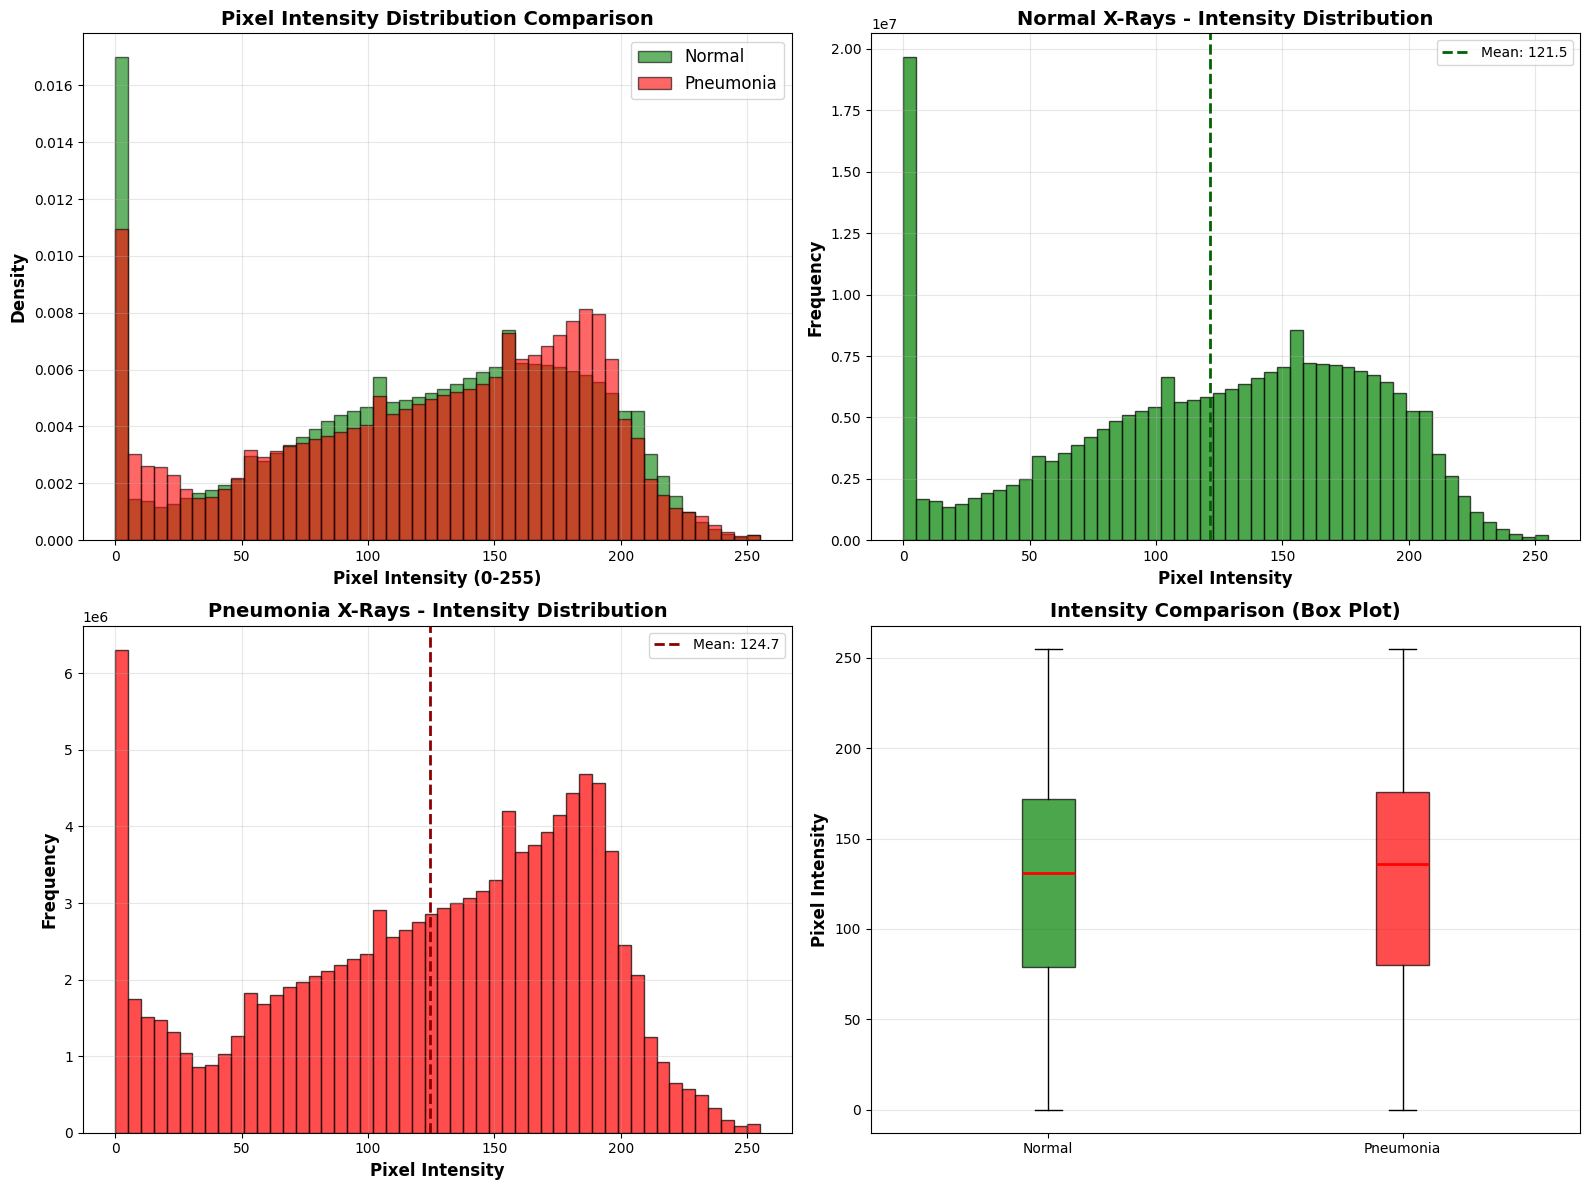

In [11]:
def sample_pixel_intensities(data_dir, class_name, split='train', num_samples=100):
    """Sample pixel intensities from images"""
    class_dir = data_dir / split / class_name
    
    image_paths = []
    for ext in IMG_EXTENSIONS:
        image_paths.extend(list(class_dir.glob(f'*{ext}')))
    
    # Random sample
    np.random.seed(42)
    selected = np.random.choice(image_paths, min(num_samples, len(image_paths)), replace=False)
    
    all_intensities = []
    for img_path in selected:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            all_intensities.extend(img.flatten())
    
    return np.array(all_intensities)

# Sample intensities
print("Sampling pixel intensities...")
normal_intensities = sample_pixel_intensities(DATA_DIR, 'NORMAL', num_samples=100)
pneumonia_intensities = sample_pixel_intensities(DATA_DIR, 'PNEUMONIA', num_samples=100)

print(f"Normal samples: {len(normal_intensities):,} pixels")
print(f"Pneumonia samples: {len(pneumonia_intensities):,} pixels")

# Statistics
print("\nIntensity Statistics (0-255 scale):")
print(f"  Normal    - Mean: {normal_intensities.mean():.2f}, Std: {normal_intensities.std():.2f}")
print(f"  Pneumonia - Mean: {pneumonia_intensities.mean():.2f}, Std: {pneumonia_intensities.std():.2f}")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram overlay
axes[0, 0].hist(normal_intensities, bins=50, alpha=0.6, label='Normal', 
                color='green', edgecolor='black', density=True)
axes[0, 0].hist(pneumonia_intensities, bins=50, alpha=0.6, label='Pneumonia', 
                color='red', edgecolor='black', density=True)
axes[0, 0].set_xlabel('Pixel Intensity (0-255)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Density', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Pixel Intensity Distribution Comparison', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=12)
axes[0, 0].grid(alpha=0.3)

# Separate histograms
axes[0, 1].hist(normal_intensities, bins=50, color='green', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(normal_intensities.mean(), color='darkgreen', linestyle='--', linewidth=2,
                   label=f'Mean: {normal_intensities.mean():.1f}')
axes[0, 1].set_xlabel('Pixel Intensity', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Normal X-Rays - Intensity Distribution', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(pneumonia_intensities, bins=50, color='red', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(pneumonia_intensities.mean(), color='darkred', linestyle='--', linewidth=2,
                   label=f'Mean: {pneumonia_intensities.mean():.1f}')
axes[1, 0].set_xlabel('Pixel Intensity', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Pneumonia X-Rays - Intensity Distribution', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Box plot comparison
bp_data = [normal_intensities, pneumonia_intensities]
bp = axes[1, 1].boxplot(bp_data, labels=['Normal', 'Pneumonia'], patch_artist=True,
                        boxprops=dict(alpha=0.7),
                        medianprops=dict(color='red', linewidth=2))
bp['boxes'][0].set_facecolor('green')
bp['boxes'][1].set_facecolor('red')
axes[1, 1].set_ylabel('Pixel Intensity', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Intensity Comparison (Box Plot)', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'intensity_analysis.png', dpi=300, bbox_inches='tight')
print(f" Intensity analysis plot saved: {RESULTS_DIR / 'intensity_analysis.png'}")
plt.show()

In [12]:

def check_data_quality(data_dir):
    """Check for corrupted images, duplicates, etc."""
    issues = {
        'corrupted': [],
        'too_small': [],
        'too_large': [],
        'unusual_aspect': []
    }
    
    total_checked = 0
    
    for split in ['train', 'test', 'val']:
        split_dir = data_dir / split
        if not split_dir.exists():
            continue
            
        for class_name in ['NORMAL', 'PNEUMONIA']:
            class_dir = split_dir / class_name
            if not class_dir.exists():
                continue
                
            image_paths = []
            for ext in IMG_EXTENSIONS:
                image_paths.extend(list(class_dir.glob(f'*{ext}')))
            
            for img_path in image_paths:
                total_checked += 1
                try:
                    img = Image.open(img_path)
                    width, height = img.size
                    
                    # Check if too small
                    if width < 100 or height < 100:
                        issues['too_small'].append(str(img_path))
                    
                    # Check if too large
                    if width > 5000 or height > 5000:
                        issues['too_large'].append(str(img_path))
                    
                    # Check aspect ratio
                    aspect_ratio = width / height
                    if aspect_ratio < 0.5 or aspect_ratio > 2.0:
                        issues['unusual_aspect'].append(str(img_path))
                    
                except Exception as e:
                    issues['corrupted'].append(str(img_path))
    
    return issues, total_checked

# Check data quality
print("Checking data quality...")
issues, total_checked = check_data_quality(DATA_DIR)

print(f"\nChecked {total_checked} images")
print("\nQuality Issues Found:")
print(f"  Corrupted images: {len(issues['corrupted'])}")
print(f"  Too small (<100px): {len(issues['too_small'])}")
print(f"  Too large (>5000px): {len(issues['too_large'])}")
print(f"  Unusual aspect ratio: {len(issues['unusual_aspect'])}")

if len(issues['corrupted']) > 0:
    print("\nCorrupted images:")
    for img_path in issues['corrupted'][:5]:
        print(f"  - {img_path}")
    if len(issues['corrupted']) > 5:
        print(f"  ... and {len(issues['corrupted']) - 5} more")

# Save quality report
quality_report = pd.DataFrame({
    'Issue Type': ['Corrupted', 'Too Small', 'Too Large', 'Unusual Aspect Ratio'],
    'Count': [len(issues['corrupted']), len(issues['too_small']), 
              len(issues['too_large']), len(issues['unusual_aspect'])]
})
quality_report.to_csv(RESULTS_DIR / 'quality_report.csv', index=False)

Checking data quality...

Checked 5856 images

Quality Issues Found:
  Corrupted images: 0
  Too small (<100px): 0
  Too large (>5000px): 0
  Unusual aspect ratio: 126


In [13]:
summary = f"""
PNEUMONIA CHEST X-RAY DATASET - EDA SUMMARY REPORT
{'='*80}

1. DATASET OVERVIEW
   - Total Images: {total_images:,}
   - Training Set: {df_stats[df_stats['Split'] == 'Train']['Count'].sum():,} images
   - Test Set: {df_stats[df_stats['Split'] == 'Test']['Count'].sum():,} images
   - Validation Set: {df_stats[df_stats['Split'] == 'Val']['Count'].sum():,} images

2. CLASS DISTRIBUTION (Training Set)
   - Normal: {normal_count:,} ({normal_count/(normal_count+pneumonia_count)*100:.1f}%)
   - Pneumonia: {pneumonia_count:,} ({pneumonia_count/(normal_count+pneumonia_count)*100:.1f}%)
   - Imbalance Ratio: 1:{pneumonia_count/normal_count:.2f}

3. IMAGE DIMENSIONS
   - Width Range: {widths.min():.0f} - {widths.max():.0f} pixels (Mean: {widths.mean():.1f})
   - Height Range: {heights.min():.0f} - {heights.max():.0f} pixels (Mean: {heights.mean():.1f})
   - Aspect Ratio: {aspect_ratios.mean():.3f} ± {aspect_ratios.std():.3f}
   - Recommended Resize: 224x224 (standard for transfer learning)

4. PIXEL INTENSITY
   - Normal X-Rays: Mean = {normal_intensities.mean():.2f}, Std = {normal_intensities.std():.2f}
   - Pneumonia X-Rays: Mean = {pneumonia_intensities.mean():.2f}, Std = {pneumonia_intensities.std():.2f}
   - Difference: {abs(normal_intensities.mean() - pneumonia_intensities.mean()):.2f} intensity units

5. DATA QUALITY
   - Total Images Checked: {total_checked:,}
   - Corrupted Images: {len(issues['corrupted'])}
   - Images Too Small: {len(issues['too_small'])}
   - Images Too Large: {len(issues['too_large'])}
   - Unusual Aspect Ratios: {len(issues['unusual_aspect'])}

6. RECOMMENDATIONS FOR PREPROCESSING
   - ✓ Resize all images to 224x224 (standard for VGG16/ResNet50)
   - ✓ Normalize pixel values to [0, 1] range
   - ✓ Apply data augmentation (rotation, flip, zoom) to address class imbalance
   - ✓ Consider class weighting during training (ratio 1:{pneumonia_count/normal_count:.2f})
   - ✓ Create proper validation split from training data (current val set is too small)

7. KEY INSIGHTS
   - Significant class imbalance favoring pneumonia cases
   - Variable image dimensions require standardization
   - Pixel intensity distributions show some separation between classes
   - Overall data quality is good with minimal corrupted images
   - Small validation set necessitates k-fold cross-validation or larger val split
"""

# Save summary report
with open(RESULTS_DIR / 'eda_summary_report.txt', 'w') as f:
    f.write(summary)

print(summary)
print(f"\n Summary report saved: {RESULTS_DIR / 'eda_summary_report.txt'}")


PNEUMONIA CHEST X-RAY DATASET - EDA SUMMARY REPORT

1. DATASET OVERVIEW
   - Total Images: 5,856
   - Training Set: 5,216 images
   - Test Set: 624 images
   - Validation Set: 16 images

2. CLASS DISTRIBUTION (Training Set)
   - Normal: 1,341 (25.7%)
   - Pneumonia: 3,875 (74.3%)
   - Imbalance Ratio: 1:2.89

3. IMAGE DIMENSIONS
   - Width Range: 438 - 2752 pixels (Mean: 1449.1)
   - Height Range: 168 - 2713 pixels (Mean: 1082.7)
   - Aspect Ratio: 1.409 ± 0.238
   - Recommended Resize: 224x224 (standard for transfer learning)

4. PIXEL INTENSITY
   - Normal X-Rays: Mean = 121.51, Std = 63.11
   - Pneumonia X-Rays: Mean = 124.69, Std = 62.48
   - Difference: 3.18 intensity units

5. DATA QUALITY
   - Total Images Checked: 5,856
   - Corrupted Images: 0
   - Images Too Small: 0
   - Images Too Large: 0
   - Unusual Aspect Ratios: 126

6. RECOMMENDATIONS FOR PREPROCESSING
   - ✓ Resize all images to 224x224 (standard for VGG16/ResNet50)
   - ✓ Normalize pixel values to [0, 1] range
   -